## Outlier

An outlier is a data value that is very different from the rest of the data.

It “stands out” because it is unusually high or unusually low compared to other values.

Example

Suppose these are student ages:

18, 19, 20, 21, 22, 95

Here, 95 is an outlier because it is far away from the normal age range.

### Why Outliers Matter in Data Cleaning
Outliers can:
* distort averages (mean)
* affect machine learning models
* create misleading graphs
* sometimes indicate data entry errors

Example:

ages = [18, 19, 20, 21, 22, 95]

Mean with outlier:

18+19+20+21+22+95/6
	=32.5

Without 95:

18+19+20+21+22/5
	​=20



### Causes of Outliers

Outliers may happen because of:

##### 1. Data Entry Errors

Example:

salary entered as 5000000 instead of 50000

##### 2. Measurement Errors

Faulty sensor/device readings.

##### 3. Natural Variation

Some values are genuinely extreme.

Example:

billionaire income in salary dataset.





### Detection and removal methods:

#### 1. Using Boxplot (Most Common)

A boxplot visually shows extreme values.
```
import seaborn as sns
sns.boxplot(df['salary'])
```

Points far from the box are possible outliers.


#### 2. Using IQR Method

Very common in data cleaning.

Formula
> IQR=Q3−Q1

Where:

* Q1 = 25th percentile
* Q3 = 75th percentile

Outlier conditions:

> x<Q1−1.5(IQR)

or

> x>Q3+1.5(IQR)

```
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['salary'] < lower) | (df['salary'] > upper)]
```

What this does
* Finds lower and upper acceptable limits
* Any value outside them is considered an outlier


#### 3. Using Z-Score

Measures how far a value is from the mean.

Formula:

> z = (x−μ)/σ
	​

### How to handle outlier:

#### 1. Remove Them

If they are errors.

```df = df[(df['salary'] >= lower) & (df['salary'] <= upper)]```

#### 2. Replace Them

Using mean/median.

```df['salary'] = df['salary'].clip(lower, upper)```

#### 3. Keep Them

If they are genuine important values.

Example:

high income in finance data



In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt


In [9]:
df = pd.read_csv('loan.csv')
df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            339 non-null    object 
 1   Gender             339 non-null    object 
 2   Married            339 non-null    object 
 3   Dependents         339 non-null    object 
 4   Education          339 non-null    object 
 5   Self_Employed      339 non-null    object 
 6   ApplicantIncome    339 non-null    int64  
 7   CoapplicantIncome  339 non-null    float64
 8   LoanAmount         48 non-null     float64
 9   Loan_Amount_Term   337 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      339 non-null    object 
 12  Loan_Status        339 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 34.6+ KB


In [11]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,339.000000,339.000000,48.000000,337.000000,338.000000
mean,6256.430678,1350.123894,211.312500,355.905045,0.863905
std,8428.737498,4474.531792,187.426259,47.505293,0.343397
min,150.000000,0.000000,6.000000,12.000000,0.000000
25%,3958.500000,0.000000,90.750000,360.000000,1.000000
50%,5000.000000,0.000000,128.000000,360.000000,1.000000
75%,5833.000000,2000.000000,285.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


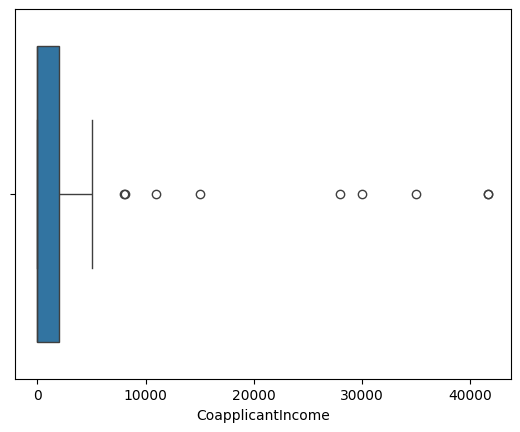

In [12]:
sns.boxplot( x = 'CoapplicantIncome', data = df)
plt.show()

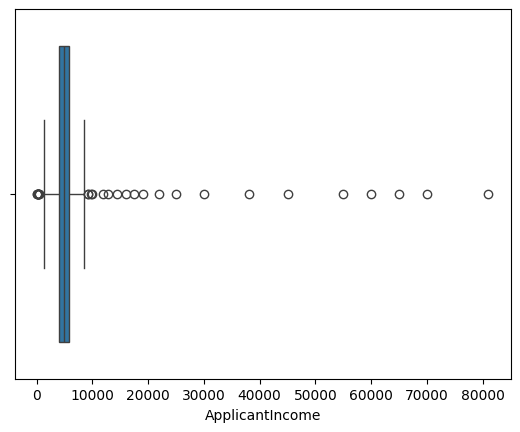

In [13]:
sns.boxplot( x = 'ApplicantIncome', data = df)
plt.show()

C:\Users\ajabe\AppData\Local\Temp\ipykernel_5648\3385199946.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ApplicantIncome'])


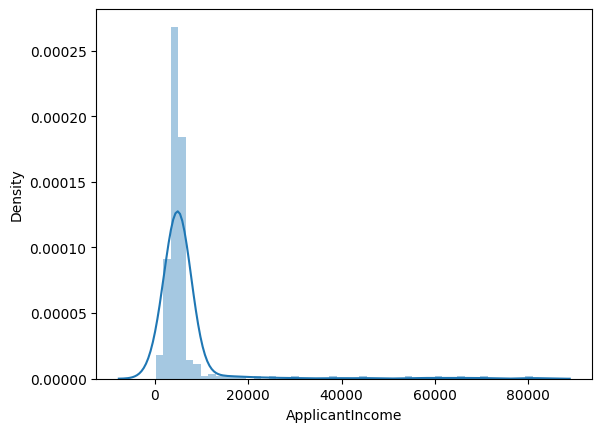

In [14]:
sns.distplot(df['ApplicantIncome'])
plt.show()

boxplot is best fit for outlier detection

In [15]:
l = [5, 6, 7, 5, 4, 6, 7, 5]
sum(l)/len(l)

5.625

In [16]:
l = [5, 6, 7, 5, 4, 6, 7, 5, 100]
sum(l)/len(l)

16.11111111111111

### IQR -- The Interquartile Range

Having percentile and quantile 

* Q1 - 25 percentile of whole dataset
* Q3 - 75 percentile of whole dataset

IQR = Q3 - Q1

min range = Q1 - (1.5 x IQR)
max range = Q3 + (1.5 x IQR)

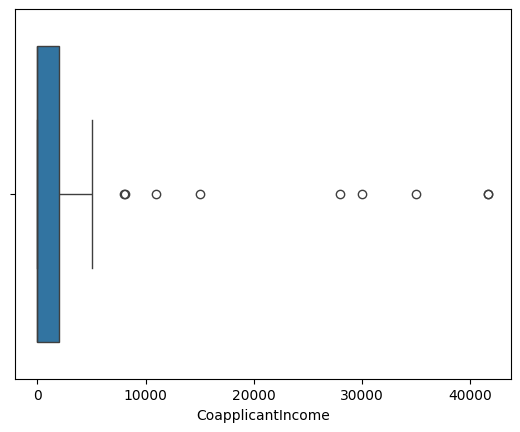

In [17]:
sns.boxplot( x = 'CoapplicantIncome', data = df)
plt.show()

In [18]:
df.shape

(339, 13)

In [22]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,339.000000,339.000000,48.000000,337.000000,338.000000
mean,6256.430678,1350.123894,211.312500,355.905045,0.863905
std,8428.737498,4474.531792,187.426259,47.505293,0.343397
min,150.000000,0.000000,6.000000,12.000000,0.000000
25%,3958.500000,0.000000,90.750000,360.000000,1.000000
50%,5000.000000,0.000000,128.000000,360.000000,1.000000
75%,5833.000000,2000.000000,285.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [19]:
q1 = df['CoapplicantIncome'].quantile(0.25)
q1

np.float64(0.0)

In [21]:
q3 = df['CoapplicantIncome'].quantile(0.75)
q3

np.float64(2000.0)

In [23]:
IQR = q3 - q1

In [26]:
min_range = q1 - (1.5 * IQR)
max_range = q3 + (1.5 * IQR)
min_range, max_range

(np.float64(-3000.0), np.float64(5000.0))

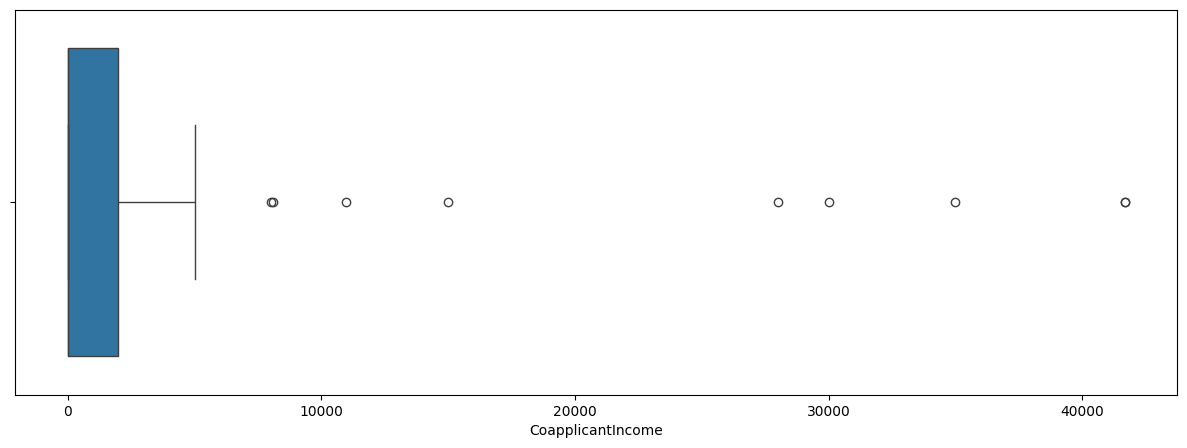

In [28]:
plt.figure(figsize = (15,5))
sns.boxplot( x = 'CoapplicantIncome', data = df)
plt.show()

In [29]:
df[df['CoapplicantIncome']<=max_range]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,LP001635,Male,No,0,Graduate,No,19000,0.0,280.0,360.0,1.0,Urban,Y
335,LP001637,Male,Yes,0,Graduate,No,300,0.0,NaN,360.0,0.0,Rural,N
336,LP001638,Female,No,0,Graduate,No,16000,0.0,240.0,360.0,1.0,Urban,Y
337,LP001639,Male,Yes,1,Graduate,No,14500,5000.0,220.0,360.0,1.0,Urban,Y


In [30]:
new_df = df[df['CoapplicantIncome']<=max_range]

In [31]:
new_df.shape

(330, 13)

9 rows of outliers been removed

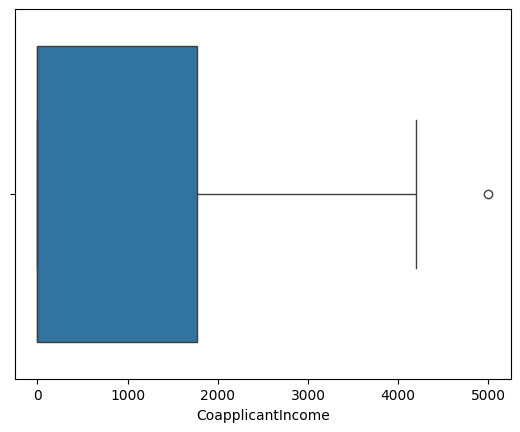

In [32]:
sns.boxplot( x = 'CoapplicantIncome', data = new_df)
plt.show()

### Z-score

* 68.26% data lies between μ-σ and μ+σ.
* 95.44% data lies between μ-2σ and μ-2σ.
* 99.72% data lies between μ-3σ and μ-3σ.

other then this is said to be outlier data

z-score:
> z = (x−μ)/σ

μ is mean, σ is standard deviation

To find min and max range like IQR set

z range: -3 and +3 

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib as plt

In [35]:
df = pd.read_csv('loan.csv')
df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [36]:
df.isnull().sum()

Loan_ID                0
Gender                 0
Married                0
Dependents             0
Education              0
Self_Employed          0
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount           291
Loan_Amount_Term       2
Credit_History         1
Property_Area          0
Loan_Status            0
dtype: int64

In [37]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,339.000000,339.000000,48.000000,337.000000,338.000000
mean,6256.430678,1350.123894,211.312500,355.905045,0.863905
std,8428.737498,4474.531792,187.426259,47.505293,0.343397
min,150.000000,0.000000,6.000000,12.000000,0.000000
25%,3958.500000,0.000000,90.750000,360.000000,1.000000
50%,5000.000000,0.000000,128.000000,360.000000,1.000000
75%,5833.000000,2000.000000,285.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


<Axes: xlabel='CoapplicantIncome'>

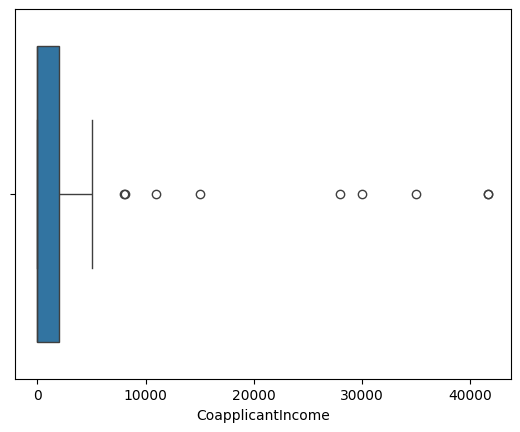

In [42]:
sns.boxplot(x='CoapplicantIncome', data = df)


C:\Users\ajabe\AppData\Local\Temp\ipykernel_5648\2149142820.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CoapplicantIncome'])


<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

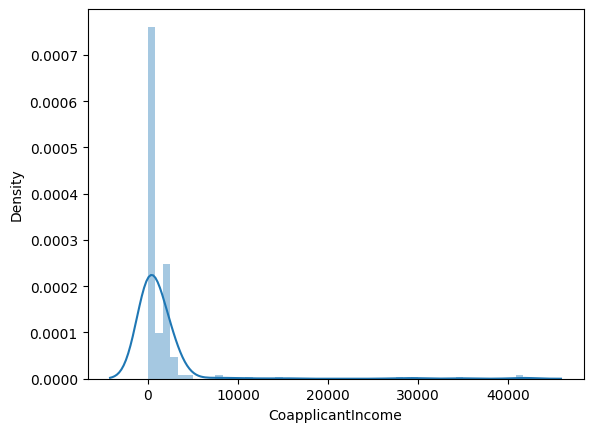

In [43]:
sns.distplot(df['CoapplicantIncome'])

Tail is too long that mean outlier is present

In [44]:
min_range = df['CoapplicantIncome'].mean()-(3*df['CoapplicantIncome'].std()) #3rd std
max_range = df['CoapplicantIncome'].mean()+(3*df['CoapplicantIncome'].std()) 

In [45]:
min_range, max_range

(np.float64(-12073.471482910109), np.float64(14773.719270520729))

Remove data outside of min and max range

In [46]:
new_data = df[df['CoapplicantIncome']<=max_range]

<Axes: xlabel='CoapplicantIncome'>

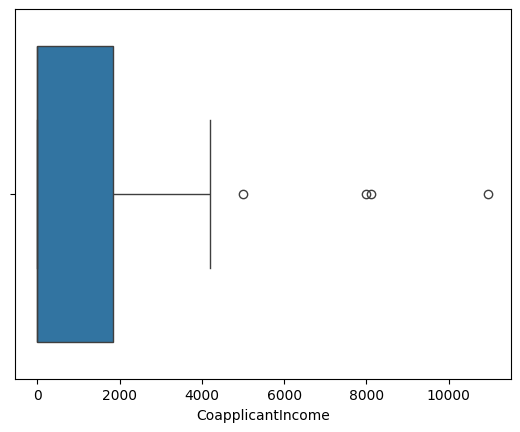

In [47]:
sns.boxplot(x='CoapplicantIncome', data = new_data)


##### by z-score

In [49]:
z_score = (df['CoapplicantIncome'] - df['CoapplicantIncome'].mean())/(df['CoapplicantIncome'].std())

In [50]:
z_score>3

0      False
1      False
2      False
3      False
4      False
       ...  
334    False
335    False
336    False
337    False
338    False
Name: CoapplicantIncome, Length: 339, dtype: bool